# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [ ]:
#code here
class NANDPerceptron:

    def __init__(self) -> None:
        self.weights = np.array([-1.0, -1.0])
        self.bias = 1.5

    def predict(self, X):
        assert X.shape[1] == 2, 'Input must be of shape (N, 2)'
        z = X @ self.weights + self.bias
        return (z >= 0).astype(int)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

nand = NANDPerceptron()
print(nand.predict(X))

[1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:** Because of step function.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**
1.As c reaches infinte , sigmoid become 1 for z >0, 0.5 for z = 0,0 for z <0.Because e^(-cz) = 0 as c approaches infinte.
2.Because it is smooth and differentiable everywhere. So, small weight changes cause small, proportional output changes.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**
The 1/2 factor cancel out while differentiating.
C(𝑤,𝑏)=1/2​(y−a)^2
dc/dw = (1/2)*2(y-a){d(y-a)/dw}

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**for n=2
1st:
(1.0−0.9)^2 =0.01
2nd:
(0.0−0.3)^2=0.09.
C=1/4(0.01+0.09)= 0.025


In [ ]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])
n = len(outputs)
C_val = np.sum((targets - outputs)**2) / (2 * n)

print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:** Bcz accuracy is not differentiable. Small changes in the network's weights often don't change the accuracy at all, so it provides no useful information.
A cost function,is continuous and differentiable. It measures how wrong the predictions are.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:****Answer:**

A problem with the absolute error cost function is that it is not differentiable at zero.Since gradient descent requires derivatives to compute weight updates,the gradient is undefined when the prediction exactly equals the target.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**
cost function is minimized when w=3 and b=1
Cmin= 0.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**
(w,b)=(0,0) and eta =0.1
dc/dw=-6, dc/db=-4
update:
w=0−0.1(−6)=0.6
b=0−0.1(−4)=0.4
after Step 1:
(w,b)=(0.6,0.4)
then , dc/dw=-4.8, dc/db=-2.4
Update:
w=0.6−0.1(−4.8)=1.08
b=0.4−0.1(−2.4)=0.64
So after Step 2:
(w,b)=(1.08,0.64)

In [58]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w - 3)
    db = 4*(b - 1)
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**
dc/db= 4(b-1)

when eta = 0.6, b goes from 0 to 2.4 to −0.96, the b value oscillates
instead of converging to 1.

In [59]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')


Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        pass

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        pass

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [60]:


    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

        grad_weights = np.zeros_like(self.weights)

        for i in range(len(self.weights)):
            w_orig = self.weights[i]

            self.weights[i] = w_orig + h
            f_plus = self.forward(x)

            self.weights[i] = w_orig - h
            f_minus = self.forward(x)

            grad_weights[i] = (f_plus - f_minus) / (2 * h)

            self.weights[i] = w_orig

        b_orig = self.bias

        self.bias = b_orig + h
        f_plus = self.forward(x)

        self.bias = b_orig - h
        f_minus = self.forward(x)

        grad_bias = (f_plus - f_minus) / (2 * h)

        self.bias = b_orig

        return grad_weights, grad_bias

**Explanation of gradient w.r.t. w1:**

> **Your answer:**

The gradient w.r.t. w1 measures how much the output changes when w1 changes slightly. Since it is positive, increasing w1 ncreases the neuron's output.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**

The sigmoid derivative is
sigma'(z)=sigma(z)(1−sigma(z)).
The gradient is largest at z=0 because sigma(0)=0.5, giving
sigm′(0)=0.5(1−0.5)=0.25,which is the maximum value of the derivative.
As z→+infinty, sigma(z)→1, and as z→−infi, sigma(z)→0. In both cases,sigma'(z)→0.This causes the vanishing gradient problem, where gradients become extremely small. As a result, weight updates during backpropagation become tiny, making learning very slow or causing deep networks to stop learning altogether.

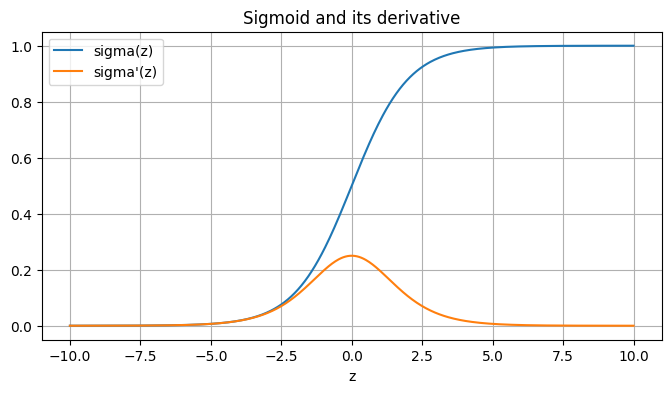

In [64]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))

plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_prime, label="sigma'(z)")

plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**

yes, its correct.
the claim breaks down near z=0.

In [ ]:
z = np.linspace(-2, 2, 1000)

sigma = 1 / (1 + np.exp(-z))
sigma_100 = 1 / (1 + np.exp(-100 * z))
step = np.where(z >= 0, 1, 0)

plt.figure(figsize=(8, 4))

plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_100, label='sigma(100z)')
plt.plot(z, step, '--', label='step function')

plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

n = len(X_train)

for epoch in range(200):

    y_pred = w * X_train + b

    loss = np.mean((y_pred - y_train) ** 2)

    dw = (2/n) * np.sum((y_pred - y_train) * X_train)
    db = (2/n) * np.sum(y_pred - y_train)

    w = w - eta * dw
    b = b - eta * db

    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**

In SGD, the gradient estimate is noisy and less accurate than the full-batch gradient.
So, the loss curve fluctuates and is less smooth than full-batch gradient descent.
Compared to full-batch GD, SGD has:
Higher noise in the gradient estimates.
Less stable loss curve with fluctuations.
Lower computational cost per update.

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    idx = np.random.randint(len(X_train))
    x = X_train[idx]
    y = y_train[idx]
    y_pred = w * x + b
    loss = (y_pred - y) ** 2
    dw = 2 * (y_pred - y) * x
    db = 2 * (y_pred - y)
    w = w - eta * dw
    b = b - eta * db

    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**

Since η=0.5 is large, each update moves the parameters too far, causing them to overshoot the minimum repeatedly. The loss increases instead of decreasing, and the parameters diverge rather than converging to w=3 and b=1.

In [ ]:
w, b = 0.0, 0.0
eta = 0.5
losses_div = []

n = len(X_train)

for epoch in range(50):

    y_pred = w * X_train + b
    loss = np.mean((y_pred - y_train) ** 2)
    dw = (2/n) * np.sum((y_pred - y_train) * X_train)
    db = (2/n) * np.sum(y_pred - y_train)
    w = w - eta * dw
    b = b - eta * db

    losses_div.append(loss)

    if not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**

[0000000011
0000111100
0011001100
0101010101]^T
b = [0
0
0
0]^T

In [ ]:

W = np.array([
    [0,0,0,0,0,0,0,0,1,1],
    [0,0,0,0,1,1,1,1,0,0],
    [0,0,1,1,0,0,1,1,0,0],
    [0,1,0,1,0,1,0,1,0,1]
], dtype=float)
b_enc = np.zeros(4)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)

for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0

    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')

    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'{digit:>5} | {out} | {expected} | {ok}')

---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**

1. The derivative DV/DC gives the slope of the curve at the current point.
2.The slope determines the direction and steepness of the descent. A large slope produces a larger step, while a small slope produces a smaller step. The learning rate ALPHA controls how far we move in that direction.

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

alpha = 0.2
v = -2.0

path_v = [v]
path_C = [(v - 2)**2 + 1]

for _ in range(8):
    grad = 2 * (v - 2)
    v = v - alpha * grad

    path_v.append(v)
    path_C.append((v - 2)**2 + 1)

plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.scatter(path_v, path_C, marker='o', label='GD steps')

for i in range(len(path_v)):
    plt.annotate(str(i), (path_v[i], path_C[i]))

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**

1. By removing all hidden layers and connecting 784 inputs directly to 10 outputs,we create a linear classifier.
2. A linear classifier can only learn linear decision boundaries. Many real-world datasets,contain complex nonlinear patterns that cannot be perfectly separated by straight lines or hyperplanes.
3.Hidden layers are necessary to capture complex patterns and achieve higher accuracy on tasks.
